# CMEMS Sea Level Data - Monthly Visualization 2024

This notebook visualizes sea level (SSH) data from CMEMS for 2024, organized by month with statistical analysis and subplots.

## 1. Import Required Libraries

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import netCDF4 
print("✓ All libraries imported successfully")


✓ All libraries imported successfully


## 2. Load and Explore the Dataset

In [11]:
# Define the data path
data_path = r"C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047 cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D 2024 01"

print(f"Data Path: {data_path}")
print(f"Path exists: {os.path.exists(data_path)}\n")

# Explore directory structure
print("=" * 70)
print("DIRECTORY STRUCTURE")
print("=" * 70)

if os.path.exists(data_path):
    for root, dirs, files in os.walk(data_path):
        level = root.replace(data_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        
        for file in files[:5]:  # Show first 5 files
            print(f'{subindent}{file}')
        
        if len(files) > 5:
            print(f'{subindent}... and {len(files) - 5} more files')
else:
    print("Path not found. Please verify the path.")

Data Path: C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047 cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D 2024 01
Path exists: True

DIRECTORY STRUCTURE
SEALEVEL_GLO_PHY_L4_MY_008_047 cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D 2024 01/
  01/
    dt_global_allsat_phy_l4_20240101_20250224.nc
    dt_global_allsat_phy_l4_20240102_20250224.nc
    dt_global_allsat_phy_l4_20240103_20250224.nc
    dt_global_allsat_phy_l4_20240104_20250224.nc
    dt_global_allsat_phy_l4_20240105_20250224.nc
    ... and 26 more files
  02/
    dt_global_allsat_phy_l4_20240201_20250224.nc
    dt_global_allsat_phy_l4_20240202_20250224.nc
    dt_global_allsat_phy_l4_20240203_20250224.nc
    dt_global_allsat_phy_l4_20240204_20250224.nc
    dt_global_allsat_phy_l4_20240205_20250224.nc
    ... and 24 more files
  03/
    dt_global_allsat_phy_l4_20240301_20250224.nc
    dt_global_allsat_phy_l4_20240302_20250224.nc
    dt_global_allsat_phy_l4_20240303_20250224.nc
    dt_global_allsat_phy_

In [12]:
# Find and load NetCDF files
nc_files = sorted(list(Path(data_path).rglob("*.nc")))

if not nc_files:
    nc_files = sorted([f for f in Path(data_path).glob("*.nc")])

print(f"\nTotal NetCDF files found: {len(nc_files)}")
print("\nSample files:")
for i, f in enumerate(nc_files[:5]):
    print(f"  {i+1}. {f.name}")

# Load and inspect the first file
if nc_files:
    print("\n" + "=" * 70)
    print("EXAMINING FIRST FILE")
    print("=" * 70)
    
    first_file = nc_files[0]
    print(f"\nFile: {first_file.name}")
    
    try:
        # Load with xarray
        ds = xr.open_dataset(first_file)
        
        print(f"\nDataset structure:")
        print(f"  Dimensions: {dict(ds.dims)}")
        print(f"\n  Variables:")
        for var in ds.data_vars:
            print(f"    - {var}: {ds[var].dims} {ds[var].shape}")
        
        print(f"\n  Coordinates:")
        for coord in ds.coords:
            print(f"    - {coord}: {ds[coord].shape}")
        
        # Check metadata
        print(f"\n  Attributes:")
        for attr_key in list(ds.attrs.keys())[:10]:
            print(f"    - {attr_key}: {str(ds.attrs[attr_key])[:60]}")
        
        ds.close()
        
    except Exception as e:
        print(f"Error loading file: {e}")


Total NetCDF files found: 366

Sample files:
  1. dt_global_allsat_phy_l4_20240101_20250224.nc
  2. dt_global_allsat_phy_l4_20240102_20250224.nc
  3. dt_global_allsat_phy_l4_20240103_20250224.nc
  4. dt_global_allsat_phy_l4_20240104_20250224.nc
  5. dt_global_allsat_phy_l4_20240105_20250224.nc

EXAMINING FIRST FILE

File: dt_global_allsat_phy_l4_20240101_20250224.nc

Dataset structure:
  Dimensions: {'latitude': 1440, 'nv': 2, 'longitude': 2880, 'time': 1}

  Variables:
    - crs: () ()
    - lat_bnds: ('latitude', 'nv') (1440, 2)
    - lon_bnds: ('longitude', 'nv') (2880, 2)
    - sla: ('time', 'latitude', 'longitude') (1, 1440, 2880)
    - err_sla: ('time', 'latitude', 'longitude') (1, 1440, 2880)
    - ugosa: ('time', 'latitude', 'longitude') (1, 1440, 2880)
    - err_ugosa: ('time', 'latitude', 'longitude') (1, 1440, 2880)
    - vgosa: ('time', 'latitude', 'longitude') (1, 1440, 2880)
    - err_vgosa: ('time', 'latitude', 'longitude') (1, 1440, 2880)
    - adt: ('time', 'latitude'

## 3. Extract Monthly Data for 2024

In [21]:
import pandas as pd
from datetime import datetime

# Dictionary to store monthly data
monthly_data = {}
file_dates_mapping = {}

print("Loading file data by month...")
print("=" * 70)

# Process each file
for nc_file in nc_files:
    try:
        ds = xr.open_dataset(nc_file)
        
        # Check if time dimension exists
        if 'time' in ds.dims:
            time_var = ds['time'].values
            
            # Convert time to datetime
            if isinstance(time_var, np.ndarray):
                dates = pd.to_datetime(time_var)
                if not isinstance(dates, pd.DatetimeIndex):
                    dates = pd.DatetimeIndex([dates])
            else:
                dates = pd.to_datetime([time_var])
            
            # Extract month and year
            month = dates[0].month
            year = dates[0].year
            
            # Identify temperature/SSH variable
            temp_var = None
            for var_name in ['sst', 'temperature', 'temp', 'adt', 'ssh', 'adt_std']:
                if var_name in ds.data_vars:
                    temp_var = var_name
                    break
            
            if not temp_var:
                # Use first data variable
                temp_var = list(ds.data_vars)[0]
            
            # Extract data
            data = ds[temp_var].values
            
            if month not in monthly_data:
                monthly_data[month] = {
                    'data': [],
                    'dates': [],
                    'variable': temp_var,
                    'files': []
                }
            
            monthly_data[month]['data'].append(data)
            monthly_data[month]['dates'].append(dates[0])
            monthly_data[month]['files'].append(nc_file.name)
            
            # print(f"✓ {nc_file.name}")
            # print(f"  Month: {month}/2024, Variable: {temp_var}, Shape: {data.shape}")
        
        ds.close()
        
    except Exception as e:
        print(f"✗ Error processing {nc_file.name}: {str(e)[:50]}")

print(f"\n{len(monthly_data)} months of data loaded successfully")
print(f"Months available: {sorted(monthly_data.keys())}")

Loading file data by month...

12 months of data loaded successfully
Months available: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## 4. Calculate Monthly Temperature Statistics

In [22]:
# Calculate monthly statistics
month_names = ['', 'January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

statistics_list = []

print("=" * 80)
print("MONTHLY STATISTICS")
print("=" * 80)

for month in sorted(monthly_data.keys()):
    month_info = monthly_data[month]
    
    # Combine all data from month
    all_data = np.concatenate([d.flatten() for d in month_info['data']])
    
    # Remove NaN values
    valid_data = all_data[~np.isnan(all_data)]
    
    if len(valid_data) > 0:
        stats = {
            'Month': month_names[month],
            'Month_Num': month,
            'Variable': month_info['variable'],
            'Mean': np.mean(valid_data),
            'Std Dev': np.std(valid_data),
            'Min': np.min(valid_data),
            'Max': np.max(valid_data),
            'Median': np.median(valid_data),
            'Count': len(valid_data),
            'Files': len(month_info['files'])
        }
        statistics_list.append(stats)
        
        print(f"\n{month_names[month]:12} | Mean: {stats['Mean']:8.3f} | "
              f"Min: {stats['Min']:8.3f} | Max: {stats['Max']:8.3f} | "
              f"Std: {stats['Std Dev']:6.3f}")

# Create DataFrame
df_stats = pd.DataFrame(statistics_list)
print(f"\n\n{df_stats.to_string(index=False)}")

# Save statistics
csv_output = 'monthly_statistics_2024.csv'
df_stats.to_csv(csv_output, index=False)
print(f"\n✓ Statistics saved to: {csv_output}")

MONTHLY STATISTICS

January      | Mean:    0.303 | Min:   -1.489 | Max:    1.863 | Std:  0.723

February     | Mean:    0.305 | Min:   -1.485 | Max:    1.895 | Std:  0.723

March        | Mean:    0.302 | Min:   -1.519 | Max:    1.965 | Std:  0.727

April        | Mean:    0.296 | Min:   -1.545 | Max:    1.969 | Std:  0.728

May          | Mean:    0.298 | Min:   -1.557 | Max:    2.033 | Std:  0.728

June         | Mean:    0.293 | Min:   -1.551 | Max:    2.037 | Std:  0.730

July         | Mean:    0.298 | Min:   -1.509 | Max:    2.098 | Std:  0.727

August       | Mean:    0.302 | Min:   -1.500 | Max:    2.098 | Std:  0.729

September    | Mean:    0.305 | Min:   -1.515 | Max:    2.166 | Std:  0.729

October      | Mean:    0.311 | Min:   -1.506 | Max:    2.174 | Std:  0.729

November     | Mean:    0.308 | Min:   -1.551 | Max:    2.153 | Std:  0.728

December     | Mean:    0.308 | Min:   -1.515 | Max:    2.130 | Std:  0.728


    Month  Month_Num Variable     Mean  Std Dev     Min

## 4.5 Visualize SSH Masked to Bay of Bengal

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Bay of Bengal bounding box
BOB_LAT_MIN, BOB_LAT_MAX = 5, 25
BOB_LON_MIN, BOB_LON_MAX = 80, 100


def visualize_ssh_bob(nc_file_path, ssh_var=None,
                      lat_bounds=(BOB_LAT_MIN, BOB_LAT_MAX),
                      lon_bounds=(BOB_LON_MIN, BOB_LON_MAX),
                      cmap='RdYlBu_r', figsize=(10, 8)):
    """
    Mask a CMEMS NetCDF file to the Bay of Bengal region and visualize SSH.

    Parameters
    ----------
    nc_file_path : str or Path
        Path to a CMEMS NetCDF file.
    ssh_var : str, optional
        Name of the SSH variable. Auto-detected if None.
    lat_bounds : tuple
        (lat_min, lat_max) for masking.
    lon_bounds : tuple
        (lon_min, lon_max) for masking.
    cmap : str
        Colormap name.
    figsize : tuple
        Figure size.

    Returns
    -------
    ds_bob : xarray.Dataset
        The masked dataset for further use.
    """
    ds = xr.open_dataset(nc_file_path)

    # Auto-detect SSH variable
    if ssh_var is None:
        for v in ['adt', 'sla', 'ssh', 'ssha']:
            if v in ds.data_vars:
                ssh_var = v
                break
        if ssh_var is None:
            ssh_var = list(ds.data_vars)[0]

    # Mask to Bay of Bengal
    ds_bob = ds.sel(
        latitude=slice(lat_bounds[0], lat_bounds[1]),
        longitude=slice(lon_bounds[0], lon_bounds[1])
    )

    ssh_data = ds_bob[ssh_var].squeeze()

    # Plot
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    im = ssh_data.plot(
        ax=ax, transform=ccrs.PlateCarree(),
        cmap=cmap, robust=True,
        cbar_kwargs={'label': f'{ssh_var.upper()} (m)', 'shrink': 0.8}
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    ax.set_extent([lon_bounds[0], lon_bounds[1],
                   lat_bounds[0], lat_bounds[1]], crs=ccrs.PlateCarree())

    # Title with date if available
    if 'time' in ds_bob.coords:
        date_str = pd.Timestamp(ds_bob.time.values.flatten()[0]).strftime('%Y-%m-%d')
        ax.set_title(f'SSH ({ssh_var.upper()}) — Bay of Bengal — {date_str}',
                     fontsize=13, fontweight='bold')
    else:
        ax.set_title(f'SSH ({ssh_var.upper()}) — Bay of Bengal',
                     fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    ds.close()
    return ds_bob


# --- Demo: visualize the first file ---
sample_file = nc_files[0]
print(f'Visualizing: {sample_file.name}')
ds_bob = visualize_ssh_bob(sample_file)

## 5. Create Monthly Subplots

Creating subplot grid: 3 rows x 4 columns (total 12 months)
✓ Subplot visualization saved: monthly_sealevel_subplots_2024.png


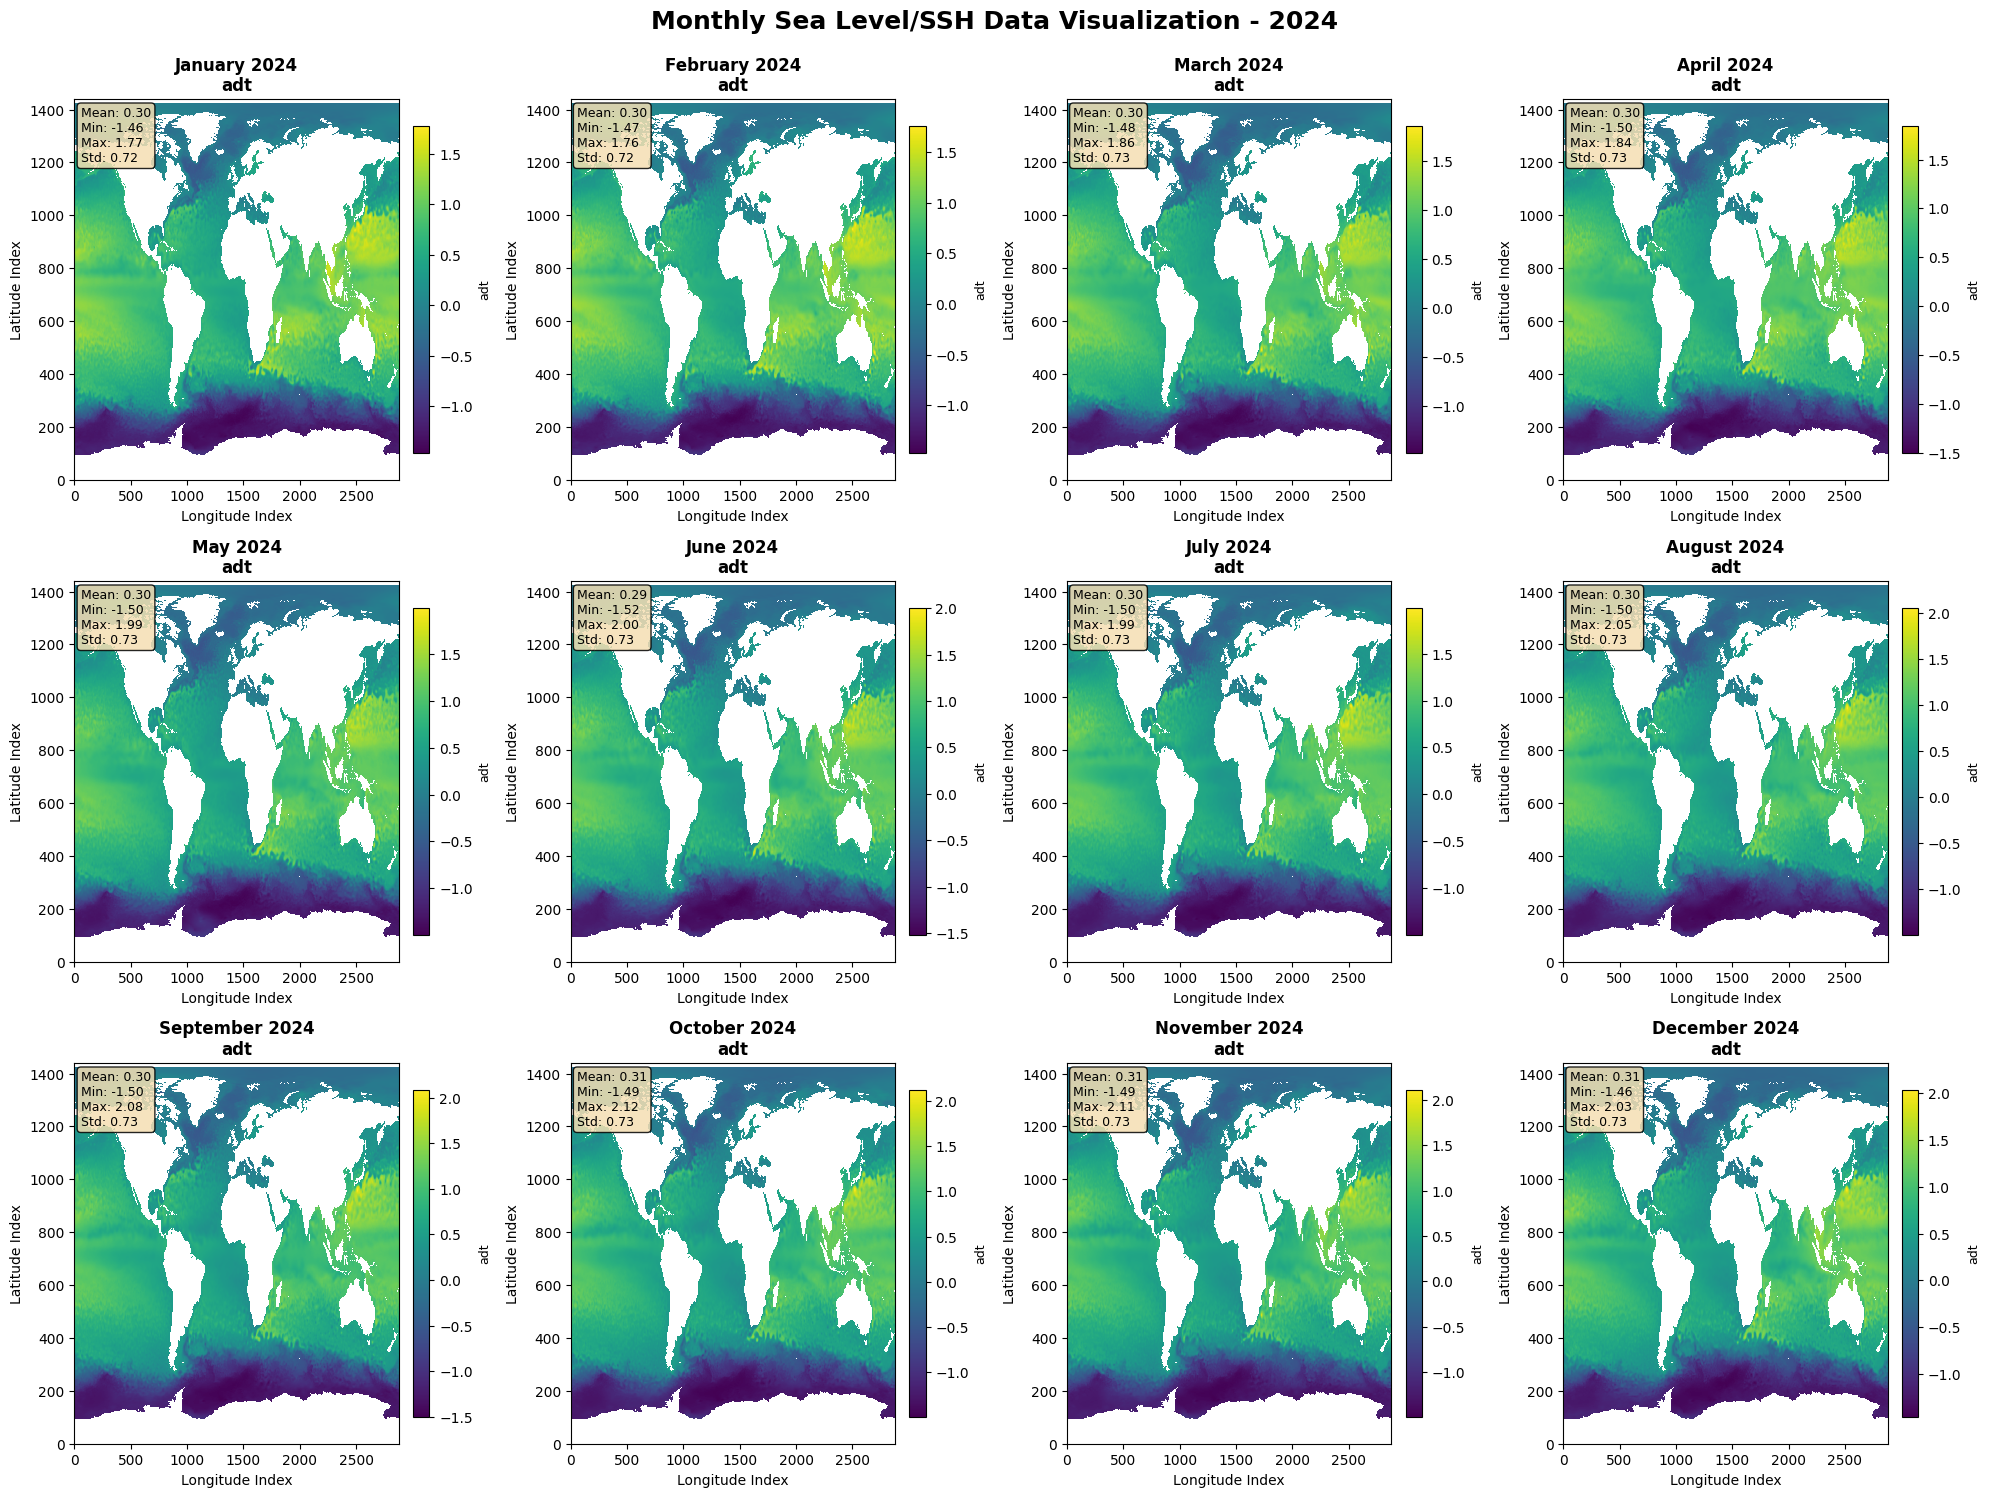

In [23]:
# Prepare data for plotting
n_months = len(monthly_data)
n_cols = 4
n_rows = (n_months + n_cols - 1) // n_cols

print(f"Creating subplot grid: {n_rows} rows x {n_cols} columns (total {n_months} months)")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
fig.suptitle('Monthly Sea Level/SSH Data Visualization - 2024', fontsize=18, fontweight='bold', y=0.995)

axes = np.atleast_1d(axes).flatten()
sorted_months = sorted(monthly_data.keys())
im = None

for idx, month in enumerate(sorted_months):
    ax = axes[idx]
    month_info = monthly_data[month]

    data_2d_list = []
    for data in month_info['data']:
        if len(data.shape) == 3:
            data_2d = np.nanmean(data, axis=0)
        elif len(data.shape) == 2:
            data_2d = data
        else:
            data_2d = np.asarray(data).reshape(-1, 1)
        data_2d_list.append(data_2d)

    if not data_2d_list:
        ax.set_visible(False)
        continue

    combined_data = np.nanmean(np.stack(data_2d_list), axis=0)
    im = ax.imshow(
        combined_data,
        cmap='viridis',
        aspect='auto',
        interpolation='nearest',
        origin='lower'
    )
    ax.set_title(f'{month_names[month]} 2024\n{month_info["variable"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude Index', fontsize=10)
    ax.set_ylabel('Latitude Index', fontsize=10)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(month_info['variable'], fontsize=9)

    valid_data = combined_data[~np.isnan(combined_data)]
    if len(valid_data) > 0:
        stats_text = (
            f'Mean: {np.mean(valid_data):.2f}\n'
            f'Min: {np.min(valid_data):.2f}\n'
            f'Max: {np.max(valid_data):.2f}\n'
            f'Std: {np.std(valid_data):.2f}'
        )
        ax.text(
            0.02,
            0.98,
            stats_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85)
        )

for idx in range(n_months, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('monthly_sealevel_subplots_2024.png', dpi=150, bbox_inches='tight')
print('✓ Subplot visualization saved: monthly_sealevel_subplots_2024.png')
plt.show()

## 6. Visualize Temperature Trends

✓ Trend analysis visualization saved: temperature_trends_2024.png


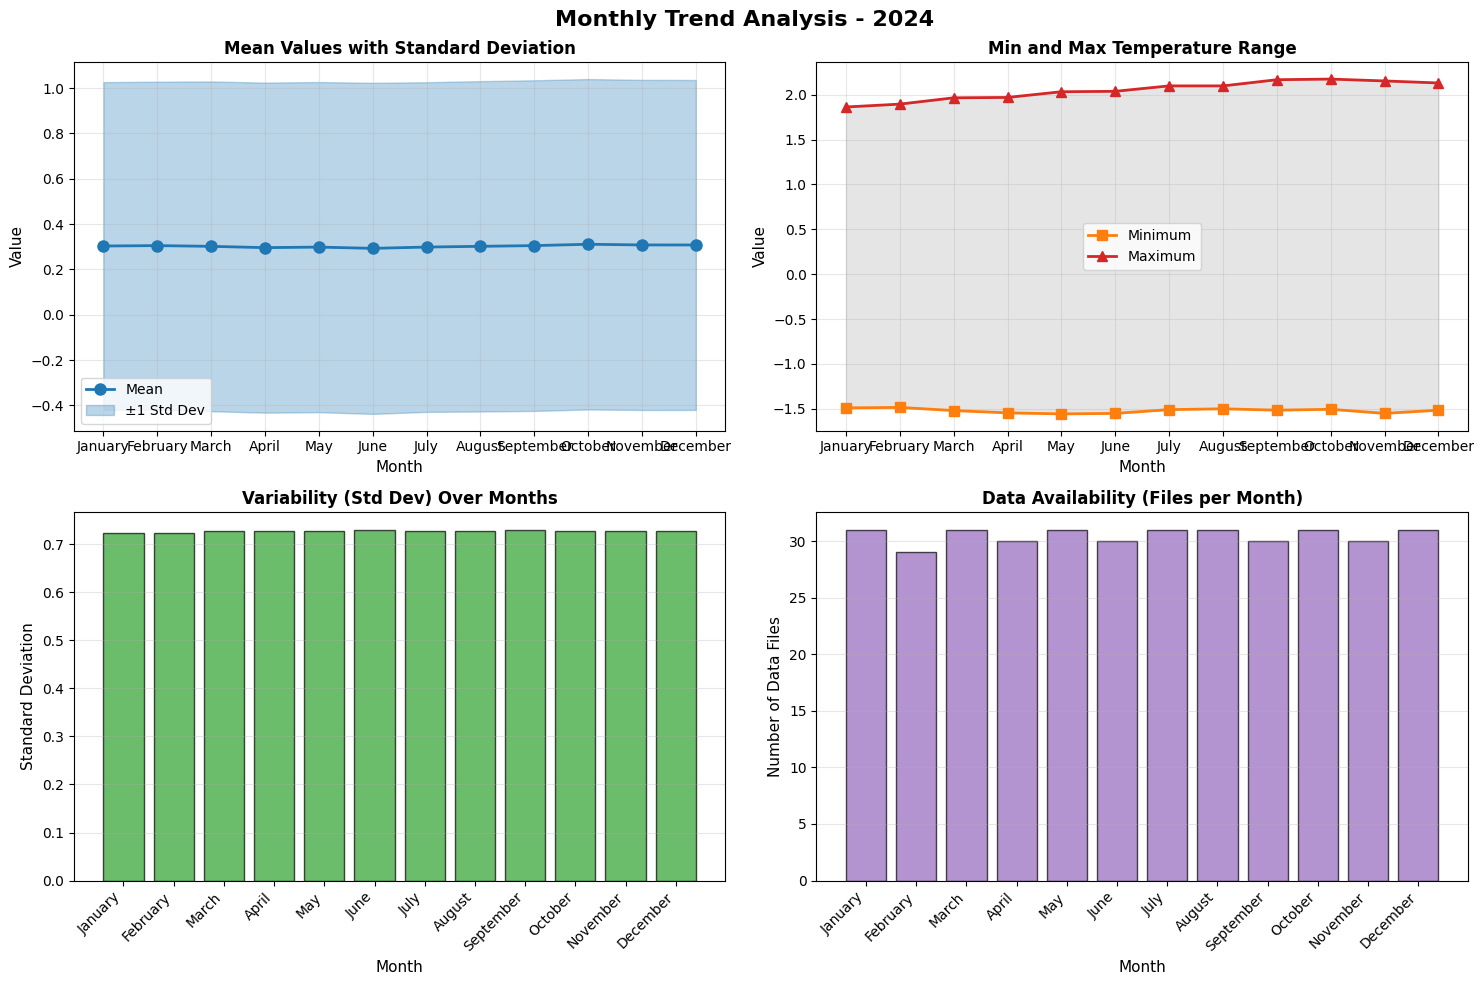


ANALYSIS COMPLETE
✓ Processed 366 NetCDF files
✓ Generated visualizations for 12 months
✓ Statistics saved to: monthly_statistics_2024.csv
✓ Subplot image: monthly_sealevel_subplots_2024.png
✓ Trend image: temperature_trends_2024.png


In [24]:
# Create trend analysis figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Monthly Trend Analysis - 2024', fontsize=16, fontweight='bold')

months_list = sorted(monthly_data.keys())
stats_for_plot = df_stats[df_stats['Month_Num'].isin(months_list)].sort_values('Month_Num')

# Plot 1: Mean values over months
ax1 = axes[0, 0]
ax1.plot(stats_for_plot['Month'], stats_for_plot['Mean'], marker='o', linewidth=2, 
         markersize=8, color='#1f77b4', label='Mean')
ax1.fill_between(range(len(stats_for_plot)), 
                  stats_for_plot['Mean'] - stats_for_plot['Std Dev'],
                  stats_for_plot['Mean'] + stats_for_plot['Std Dev'],
                  alpha=0.3, color='#1f77b4', label='±1 Std Dev')
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Value', fontsize=11)
ax1.set_title('Mean Values with Standard Deviation', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Min and Max values
ax2 = axes[0, 1]
ax2.plot(stats_for_plot['Month'], stats_for_plot['Min'], marker='s', linewidth=2, 
         markersize=7, color='#ff7f0e', label='Minimum')
ax2.plot(stats_for_plot['Month'], stats_for_plot['Max'], marker='^', linewidth=2, 
         markersize=7, color='#d62728', label='Maximum')
ax2.fill_between(range(len(stats_for_plot)), 
                  stats_for_plot['Min'], stats_for_plot['Max'],
                  alpha=0.2, color='gray')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Value', fontsize=11)
ax2.set_title('Min and Max Temperature Range', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Standard Deviation over months
ax3 = axes[1, 0]
ax3.bar(range(len(stats_for_plot)), stats_for_plot['Std Dev'], 
        color='#2ca02c', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Month', fontsize=11)
ax3.set_ylabel('Standard Deviation', fontsize=11)
ax3.set_title('Variability (Std Dev) Over Months', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(stats_for_plot)))
ax3.set_xticklabels(stats_for_plot['Month'], rotation=45, ha='right')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Data count availability
ax4 = axes[1, 1]
ax4.bar(range(len(stats_for_plot)), stats_for_plot['Files'], 
        color='#9467bd', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Month', fontsize=11)
ax4.set_ylabel('Number of Data Files', fontsize=11)
ax4.set_title('Data Availability (Files per Month)', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(stats_for_plot)))
ax4.set_xticklabels(stats_for_plot['Month'], rotation=45, ha='right')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temperature_trends_2024.png', dpi=150, bbox_inches='tight')
print("✓ Trend analysis visualization saved: temperature_trends_2024.png")
plt.show()

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print(f"✓ Processed {len(nc_files)} NetCDF files")
print(f"✓ Generated visualizations for {len(months_list)} months")
print(f"✓ Statistics saved to: monthly_statistics_2024.csv")
print(f"✓ Subplot image: monthly_sealevel_subplots_2024.png")
print(f"✓ Trend image: temperature_trends_2024.png")

## 7. Daywise Exploration within a Month

Analyzing January 2024 - Daywise Data
✓ Found data for 31 days in January
Days available: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
✓ Daywise visualization saved: daywise_january_2024.png


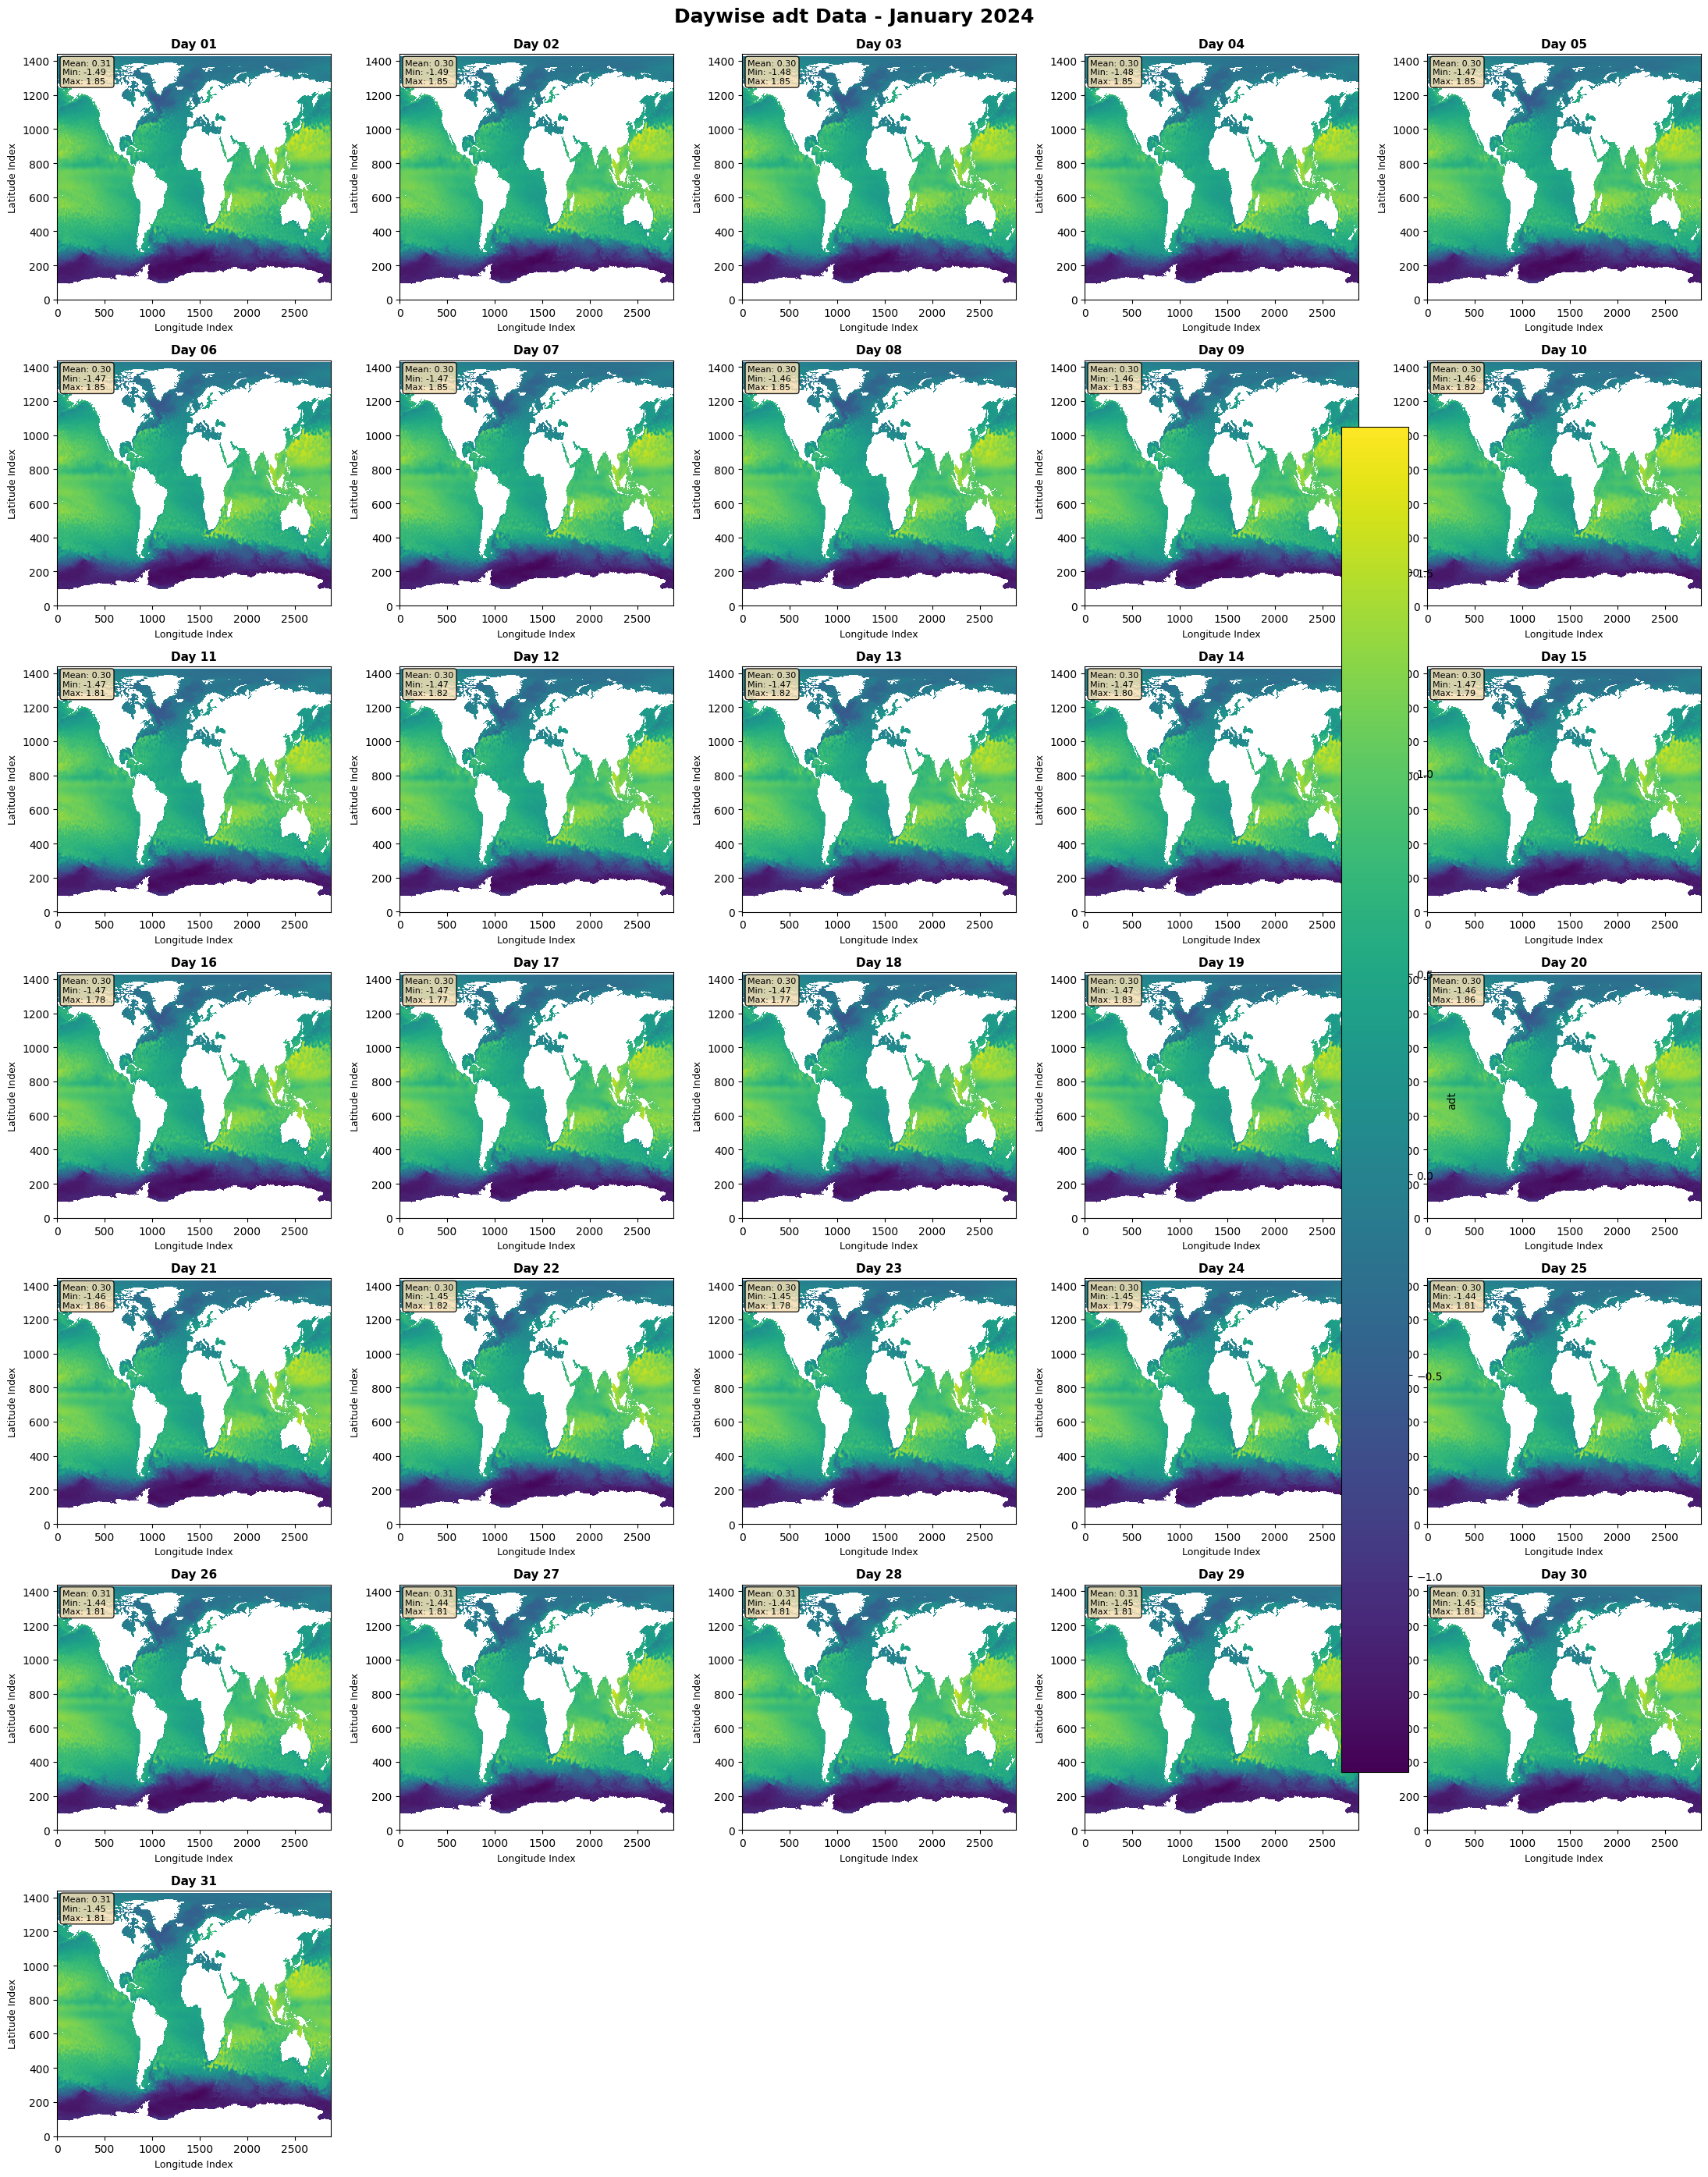

In [25]:
# Select a month for daywise analysis
selected_month = 1

print(f"Analyzing {month_names[selected_month]} 2024 - Daywise Data")
print('=' * 80)

if selected_month in monthly_data:
    month_info = monthly_data[selected_month]
    temp_var = month_info['variable']
    daily_data = {}

    for nc_file_name in month_info['files']:
        matches = list(Path(data_path).rglob(nc_file_name))
        if not matches:
            continue

        nc_file = matches[0]
        try:
            ds = xr.open_dataset(nc_file)
            if 'time' in ds.dims:
                dates = pd.to_datetime(ds['time'].values)
                if not isinstance(dates, pd.DatetimeIndex):
                    dates = pd.DatetimeIndex([dates])

                data = ds[temp_var].values
                for t_idx, date in enumerate(dates):
                    day = date.day
                    time_slice = data[t_idx] if len(data.shape) == 3 else data
                    daily_data.setdefault(day, []).append(time_slice)
            ds.close()
        except Exception as error:
            print(f"Error processing {nc_file.name}: {str(error)[:80]}")

    print(f"✓ Found data for {len(daily_data)} days in {month_names[selected_month]}")
    print(f"Days available: {sorted(daily_data.keys())}")

    if daily_data:
        sorted_days = sorted(daily_data.keys())
        n_days = len(sorted_days)
        n_cols = 5
        n_rows = (n_days + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
        fig.suptitle(
            f'Daywise {temp_var} Data - {month_names[selected_month]} 2024',
            fontsize=18,
            fontweight='bold',
            y=0.995
        )

        axes = np.atleast_1d(axes).flatten()
        global_min = np.inf
        global_max = -np.inf

        for day in sorted_days:
            day_combined = np.nanmean(np.stack(daily_data[day]), axis=0)
            global_min = min(global_min, np.nanmin(day_combined))
            global_max = max(global_max, np.nanmax(day_combined))

        im = None
        for idx, day in enumerate(sorted_days):
            ax = axes[idx]
            day_combined = np.nanmean(np.stack(daily_data[day]), axis=0)
            im = ax.imshow(
                day_combined,
                cmap='viridis',
                aspect='auto',
                interpolation='nearest',
                origin='lower',
                vmin=global_min,
                vmax=global_max
            )
            ax.set_title(f'Day {day:02d}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Longitude Index', fontsize=9)
            ax.set_ylabel('Latitude Index', fontsize=9)

            valid_data = day_combined[~np.isnan(day_combined)]
            if len(valid_data) > 0:
                stats_text = (
                    f'Mean: {np.mean(valid_data):.2f}\n'
                    f'Min: {np.min(valid_data):.2f}\n'
                    f'Max: {np.max(valid_data):.2f}'
                )
                ax.text(
                    0.02,
                    0.98,
                    stats_text,
                    transform=ax.transAxes,
                    fontsize=8,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85)
                )

        for idx in range(n_days, len(axes)):
            axes[idx].axis('off')

        if im is not None:
            fig.colorbar(im, ax=axes[:n_days], label=temp_var, shrink=0.8, pad=0.02)

        plt.tight_layout()
        filename = f'daywise_{month_names[selected_month].lower()}_2024.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"✓ Daywise visualization saved: {filename}")
        plt.show()
else:
    print(f"No data available for month {selected_month}")

TRYING MONTH 1 (January):

DAYWISE ANALYSIS: January 2024

 Day     Mean     Min    Max      Std
   1 0.305058 -1.4894 1.8514 0.723395
   2 0.304696 -1.4869 1.8485 0.723404
   3 0.304229 -1.4833 1.8474 0.723449
   4 0.303724 -1.4787 1.8479 0.723480
   5 0.303245 -1.4738 1.8457 0.723452
   6 0.302833 -1.4696 1.8501 0.723329
   7 0.302492 -1.4661 1.8513 0.723103
   8 0.302205 -1.4638 1.8456 0.722801
   9 0.301949 -1.4624 1.8322 0.722478
  10 0.301713 -1.4638 1.8224 0.722203
  11 0.301508 -1.4656 1.8138 0.722037
  12 0.301351 -1.4673 1.8161 0.722018
  13 0.301262 -1.4689 1.8190 0.722146
  14 0.301252 -1.4701 1.8024 0.722389
  15 0.301316 -1.4707 1.7904 0.722692
  16 0.301424 -1.4709 1.7795 0.722999
  17 0.301541 -1.4704 1.7651 0.723266
  18 0.301650 -1.4689 1.7650 0.723472
  19 0.301764 -1.4665 1.8301 0.723597
  20 0.301925 -1.4629 1.8626 0.723630
  21 0.302184 -1.4587 1.8604 0.723570
  22 0.302587 -1.4540 1.8223 0.723423
  23 0.303143 -1.4497 1.7824 0.723213
  24 0.303813 -1.4461 1.7949 

KeyboardInterrupt: 

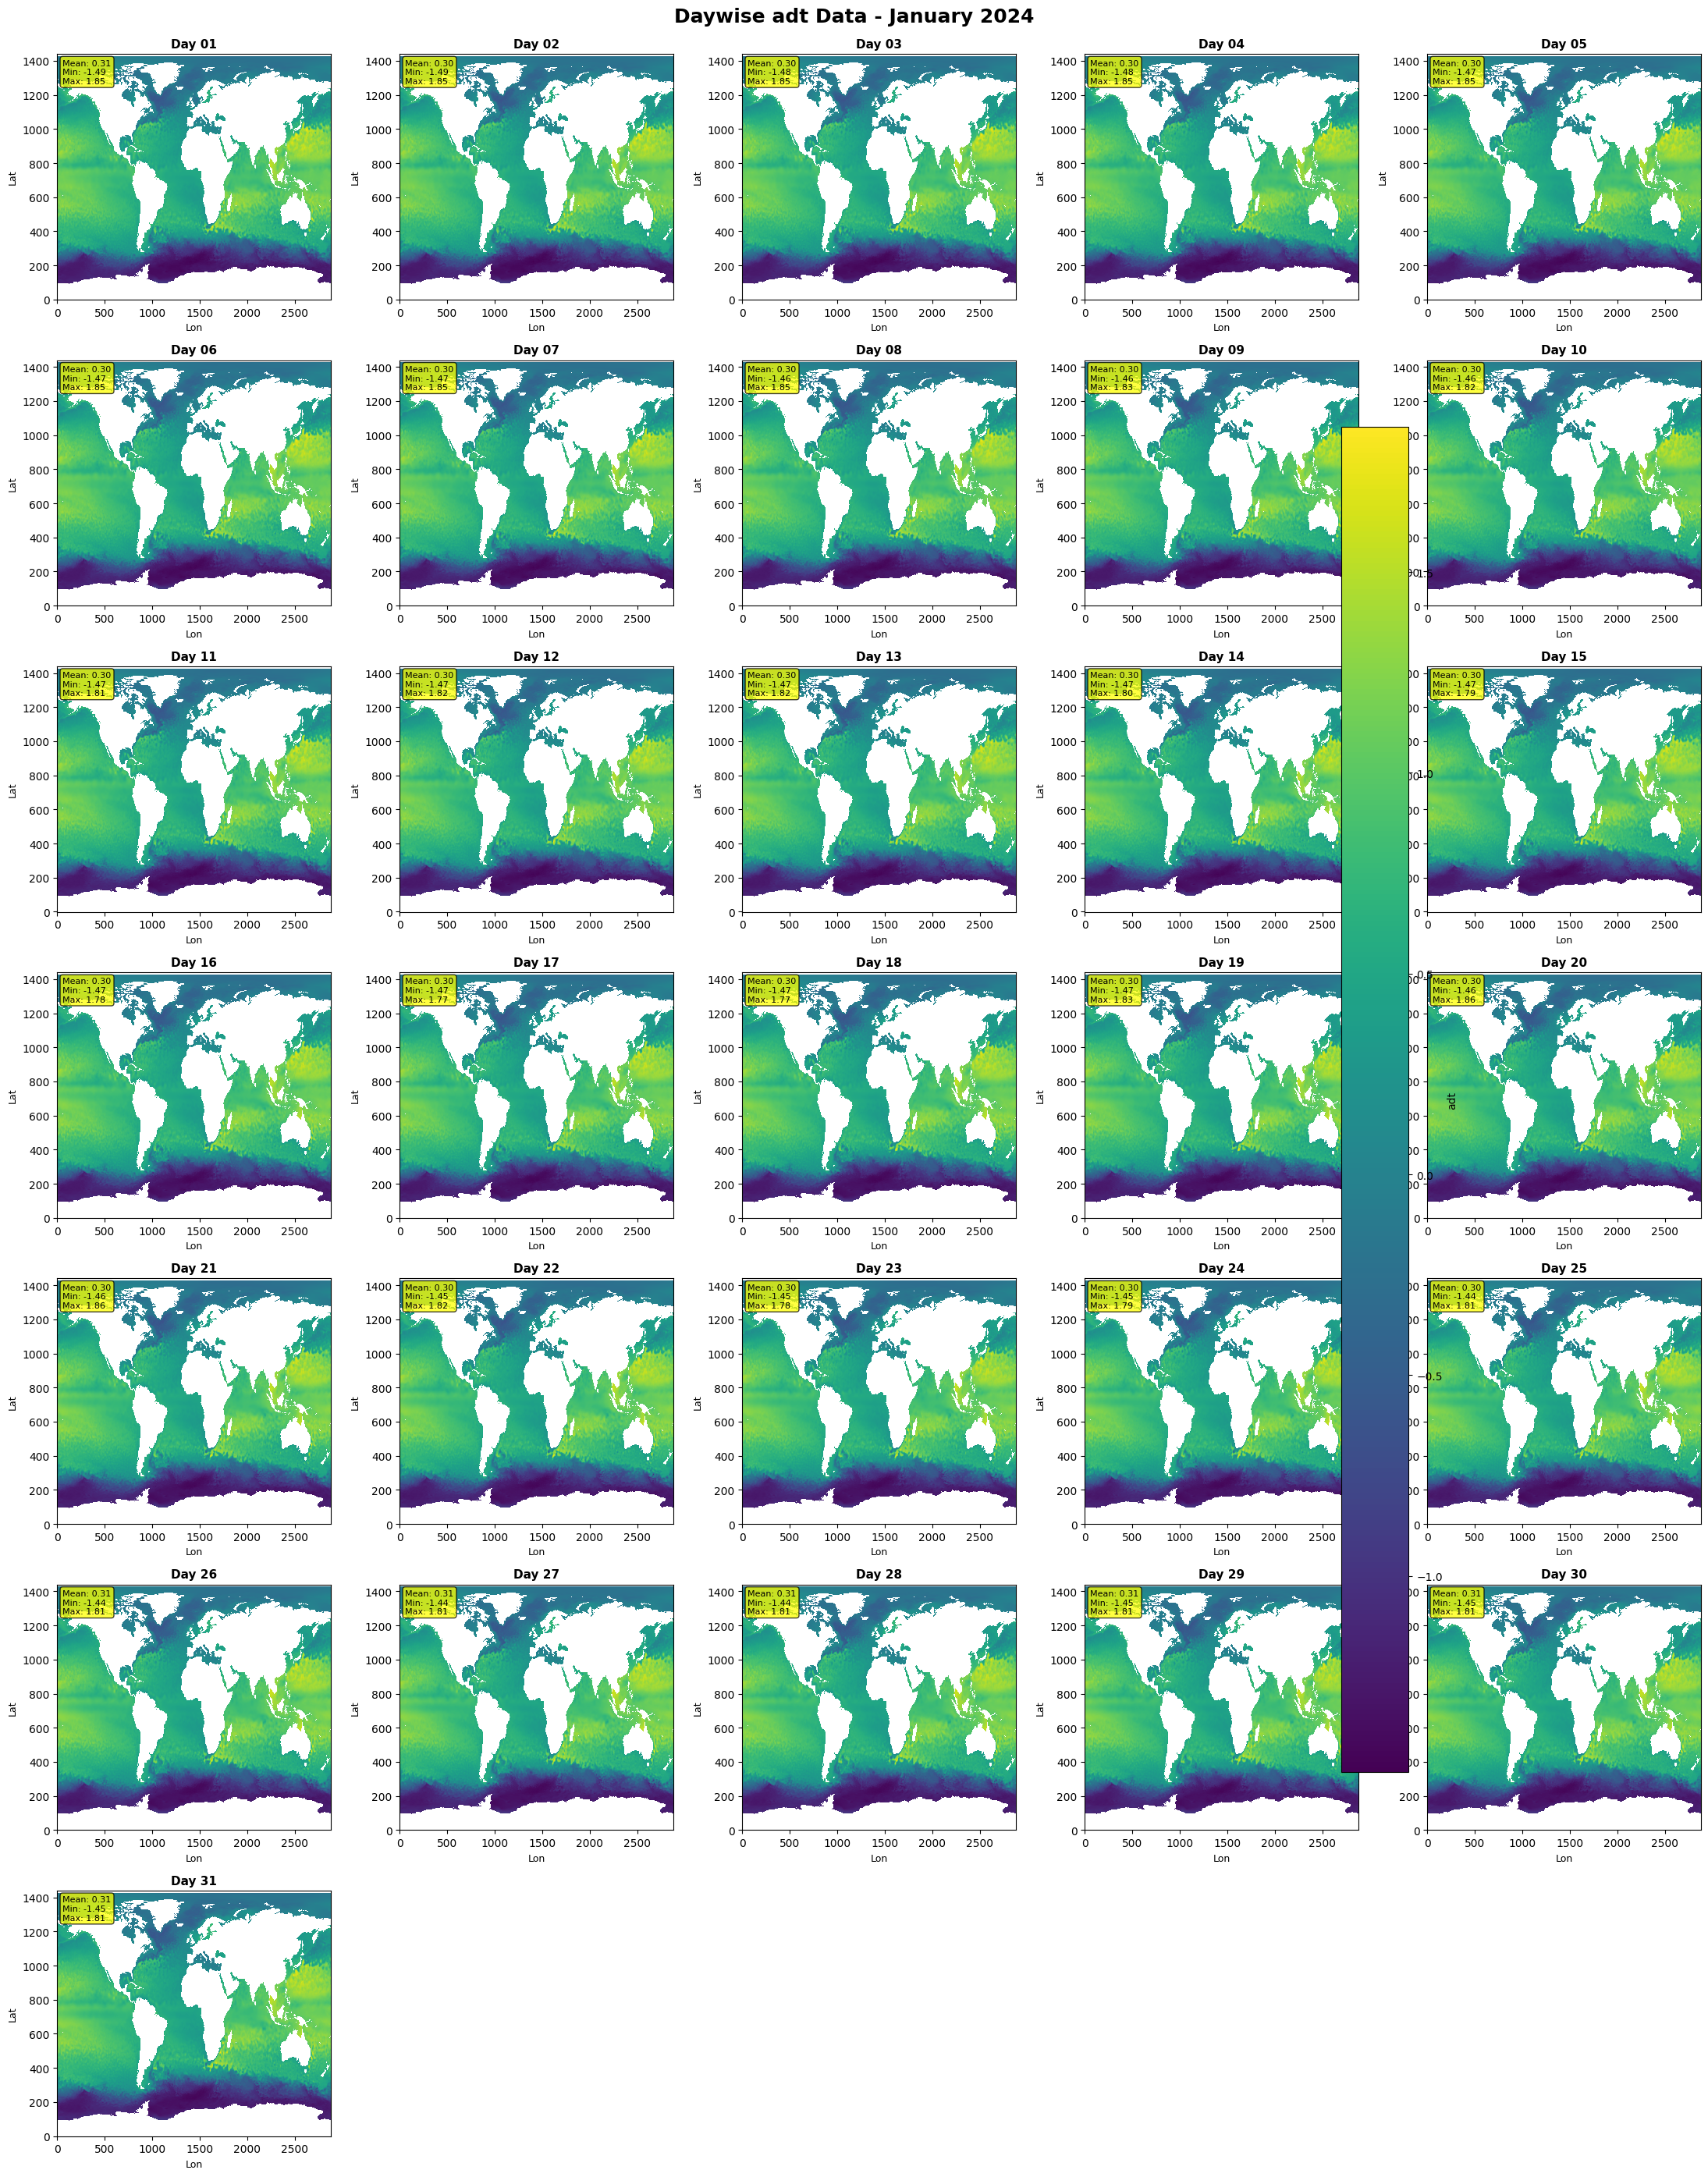

In [26]:
# Function for interactive month selection and daywise visualization
def visualize_daywise_data(target_month):
    print(f"\n{'=' * 80}")
    print(f"DAYWISE ANALYSIS: {month_names[target_month]} 2024")
    print(f"{'=' * 80}\n")

    if target_month not in monthly_data:
        print(f"No data available for month {target_month}")
        return

    month_info = monthly_data[target_month]
    temp_var = month_info['variable']
    daily_data = {}

    for nc_file_name in month_info['files']:
        matches = list(Path(data_path).rglob(nc_file_name))
        if not matches:
            continue

        nc_file = matches[0]
        try:
            ds = xr.open_dataset(nc_file)
            if 'time' in ds.dims:
                dates = pd.to_datetime(ds['time'].values)
                if not isinstance(dates, pd.DatetimeIndex):
                    dates = pd.DatetimeIndex([dates])

                data = ds[temp_var].values
                for t_idx, date in enumerate(dates):
                    day = date.day
                    time_slice = data[t_idx] if len(data.shape) == 3 else data
                    daily_data.setdefault(day, []).append(time_slice)
            ds.close()
        except Exception:
            continue

    if not daily_data:
        print(f"Could not load daily data for {month_names[target_month]}")
        return

    sorted_days = sorted(daily_data.keys())
    daily_stats = []
    for day in sorted_days:
        day_combined = np.nanmean(np.stack(daily_data[day]), axis=0)
        valid_data = day_combined[~np.isnan(day_combined)]
        if len(valid_data) > 0:
            daily_stats.append({
                'Day': day,
                'Mean': np.mean(valid_data),
                'Min': np.min(valid_data),
                'Max': np.max(valid_data),
                'Std': np.std(valid_data)
            })

    df_daily = pd.DataFrame(daily_stats)
    print(df_daily.to_string(index=False))

    n_days = len(sorted_days)
    n_cols = 5
    n_rows = (n_days + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
    fig.suptitle(f'Daywise {temp_var} Data - {month_names[target_month]} 2024', fontsize=18, fontweight='bold', y=0.995)
    axes = np.atleast_1d(axes).flatten()

    global_min = np.inf
    global_max = -np.inf
    for day in sorted_days:
        day_combined = np.nanmean(np.stack(daily_data[day]), axis=0)
        global_min = min(global_min, np.nanmin(day_combined))
        global_max = max(global_max, np.nanmax(day_combined))

    im = None
    for idx, day in enumerate(sorted_days):
        ax = axes[idx]
        day_combined = np.nanmean(np.stack(daily_data[day]), axis=0)
        im = ax.imshow(
            day_combined,
            cmap='viridis',
            aspect='auto',
            interpolation='nearest',
            origin='lower',
            vmin=global_min,
            vmax=global_max
        )
        ax.set_title(f'Day {day:02d}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Lon', fontsize=9)
        ax.set_ylabel('Lat', fontsize=9)

        valid_data = day_combined[~np.isnan(day_combined)]
        if len(valid_data) > 0:
            stats_text = (
                f'Mean: {np.mean(valid_data):.2f}\n'
                f'Min: {np.min(valid_data):.2f}\n'
                f'Max: {np.max(valid_data):.2f}'
            )
            ax.text(
                0.02,
                0.98,
                stats_text,
                transform=ax.transAxes,
                fontsize=8,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.75)
            )

    for idx in range(n_days, len(axes)):
        axes[idx].axis('off')

    if im is not None:
        fig.colorbar(im, ax=axes[:n_days], label=temp_var, shrink=0.8, pad=0.02)

    plt.tight_layout()
    filename = f'daywise_{month_names[target_month].lower()}_2024.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\nSaved: {filename}")
    plt.show()

print('TRYING MONTH 1 (January):')
visualize_daywise_data(1)